In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import featuretools as ft
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('excelTry.csv')
df.head()

,Week number,DATE,A(H1N1),A(H3N2),A(unknown),B,Positivity (%)*,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),...,Influenza 2017-2018 (%),T2M,QV2M,PRECTOTCORR,WS10M_RANGE,PS,NO,PM2.5,SO,CO
0,23,04/06/2015,0,0,0,1,0.0,0.0,0.0,0.0,...,0.0,11.946286,6.570571,2.505714,6.024857,100.493714,0.001473,9.7296,0.005577,506.718000
1,40,01/10/2015,0,3,5,6,0.0,0.0,0.0,0.0,...,0.0,11.740286,6.937143,0.078857,2.657714,102.480000,0.005648,11.6860,0.008509,427.469429
2,41,08/10/2015,6,2,21,2,0.0,0.0,0.0,0.0,...,0.0,12.106857,7.811714,3.934857,3.706857,100.503714,0.005648,11.6860,0.008509,751.117143
3,42,15/10/2015,7,0,6,5,0.0,0.0,0.0,0.0,...,0.0,9.672000,6.202857,0.484286,3.170000,101.436286,0.005648,11.6860,0.008509,462.478571
4,43,22/10/2015,6,1,5,4,0.0,0.0,0.0,0.0,...,0.0,10.287143,6.838571,1.617714,3.145143,101.372000,0.005648,11.6860,0.008509,577.775857


In [3]:
df.tail()

,Week number,DATE,A(H1N1),A(H3N2),A(unknown),B,Positivity (%)*,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),...,Influenza 2017-2018 (%),T2M,QV2M,PRECTOTCORR,WS10M_RANGE,PS,NO,PM2.5,SO,CO
367,25,20/06/2024,0,18,25,6,0.0,0.0,0.0,0.0,...,0.0,13.256786,7.896705,2.124140,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429
368,26,27/06/2024,1,16,16,0,0.0,0.0,0.0,0.0,...,0.0,16.717419,9.859756,0.400032,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000
369,27,04/07/2024,3,13,12,6,0.0,0.0,0.0,0.0,...,0.0,13.947321,8.123555,1.976169,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429
370,28,11/07/2024,0,29,18,4,0.0,0.0,0.0,0.0,...,0.0,14.340097,8.745812,6.230974,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714
371,29,18/07/2024,2,42,27,8,0.0,0.0,0.0,0.0,...,0.0,17.872841,10.548295,0.088182,2.674659,101.024546,0.277300,9.293000,1.520000,216.240000


In [4]:
#check for null 
df.isnull().sum()

Week number                0
DATE                       0
A(H1N1)                    0
A(H3N2)                    0
A(unknown)                 0
B                          0
Positivity (%)*            0
Influenza 2022-2023 (%)    0
Influenza 2021-2022 (%)    0
Influenza 2020-2021 (%)    0
Influenza 2019-2020 (%)    0
Influenza 2018-2019 (%)    0
Influenza 2017-2018 (%)    0
T2M                        0
QV2M                       0
PRECTOTCORR                0
WS10M_RANGE                0
PS                         0
NO                         0
PM2.5                      0
SO                         0
CO                         0
dtype: int64

In [5]:
df=df.dropna()

In [6]:
# Dropping columns that are not needed 

df.drop(columns=['Positivity (%)*'], inplace=True)

In [7]:
columns_to_modify = ['Influenza 2022-2023 (%)',
                     'Influenza 2021-2022 (%)',
                     'Influenza 2020-2021 (%)',
                     'Influenza 2019-2020 (%)',
                     'Influenza 2018-2019 (%)',
                     'Influenza 2017-2018 (%)']

# Replace 0s with NaN in the specified columns
df[columns_to_modify] = df[columns_to_modify].replace(0, np.nan)

# Replace NaNs with the column mean in the specified columns
df[columns_to_modify] = df[columns_to_modify].fillna(df[columns_to_modify].mean())

# Display the updated dataframe for verification
df[columns_to_modify].head()  

,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),Influenza 2019-2020 (%),Influenza 2018-2019 (%),Influenza 2017-2018 (%)
0,1.283333,0.136364,6.260976,5.226923,6.942308,8.463462
1,1.283333,0.136364,6.260976,5.226923,6.942308,8.463462
2,1.283333,0.136364,6.260976,5.226923,6.942308,8.463462
3,1.283333,0.136364,6.260976,5.226923,6.942308,8.463462
4,1.283333,0.136364,6.260976,5.226923,6.942308,8.463462


In [8]:
df.describe(include='all')

,Week number,DATE,A(H1N1),A(H3N2),A(unknown),B,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),Influenza 2019-2020 (%),...,Influenza 2017-2018 (%),T2M,QV2M,PRECTOTCORR,WS10M_RANGE,PS,NO,PM2.5,SO,CO
count,372.000000,372,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,...,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,04/06/2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,26.048387,NaN,12.048387,40.228495,134.551075,59.967742,1.283333,0.136364,6.260976,5.226923,...,8.463462,9.350942,6.516272,2.201755,4.198966,100.673573,0.472830,10.572645,1.625602,308.315234
std,16.520928,NaN,26.559252,120.695129,288.571881,203.438406,0.569477,0.011714,3.254586,4.071029,...,5.046052,4.787418,1.772980,1.655273,1.148624,0.893687,0.649313,4.092779,1.816599,166.863455
min,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.100000,0.100000,0.100000,0.400000,...,0.400000,-1.122000,2.667143,0.037143,1.897143,98.056286,0.000444,3.241143,0.002895,0.000000
25%,11.000000,NaN,0.000000,0.000000,1.000000,1.000000,1.283333,0.136364,6.260976,5.226923,...,8.463462,5.827429,5.138368,0.729786,3.310286,100.123000,0.002532,7.622200,0.005568,208.588929
50%,24.000000,NaN,1.000000,6.000000,17.000000,5.000000,1.283333,0.136364,6.260976,5.226923,...,8.463462,8.495054,6.188429,1.979286,4.031795,100.725857,0.227886,9.754229,1.499286,269.187143
75%,42.000000,NaN,8.000000,24.000000,83.000000,25.000000,1.283333,0.136364,6.260976,5.226923,...,8.463462,12.485000,7.721500,3.324250,4.951286,101.304214,0.760550,12.504500,2.668929,377.958286


In [9]:
# Check for duplicate rows in the entire DataFrame
duplicate_rows = df[df.duplicated()]

# Display the duplicate rows
print(duplicate_rows)

Empty DataFrame
Columns: [Week number, DATE, A(H1N1), A(H3N2), A(unknown), B, Influenza 2022-2023 (%), Influenza 2021-2022 (%), Influenza 2020-2021 (%), Influenza 2019-2020 (%), Influenza 2018-2019 (%), Influenza 2017-2018 (%), T2M, QV2M, PRECTOTCORR, WS10M_RANGE, PS, NO, PM2.5, SO, CO]
Index: []

[0 rows x 21 columns]


In [10]:
df

,Week number,DATE,A(H1N1),A(H3N2),A(unknown),B,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),Influenza 2019-2020 (%),...,Influenza 2017-2018 (%),T2M,QV2M,PRECTOTCORR,WS10M_RANGE,PS,NO,PM2.5,SO,CO
0,23,04/06/2015,0,0,0,1,1.283333,0.136364,6.260976,5.226923,...,8.463462,11.946286,6.570571,2.505714,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000
1,40,01/10/2015,0,3,5,6,1.283333,0.136364,6.260976,5.226923,...,8.463462,11.740286,6.937143,0.078857,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429
2,41,08/10/2015,6,2,21,2,1.283333,0.136364,6.260976,5.226923,...,8.463462,12.106857,7.811714,3.934857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143
3,42,15/10/2015,7,0,6,5,1.283333,0.136364,6.260976,5.226923,...,8.463462,9.672000,6.202857,0.484286,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571
4,43,22/10/2015,6,1,5,4,1.283333,0.136364,6.260976,5.226923,...,8.463462,10.287143,6.838571,1.617714,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25,20/06/2024,0,18,25,6,1.283333,0.136364,6.260976,5.226923,...,8.463462,13.256786,7.896705,2.124140,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429
368,26,27/06/2024,1,16,16,0,1.283333,0.136364,6.260976,5.226923,...,8.463462,16.717419,9.859756,0.400032,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000
369,27,04/07/2024,3,13,12,6,1.283333,0.136364,6.260976,5.226923,...,8.463462,13.947321,8.123555,1.976169,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429
370,28,11/07/2024,0,29,18,4,1.283333,0.136364,6.260976,5.226923,...,8.463462,14.340097,8.745812,6.230974,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714


In [11]:
#lets rename some of the data variables
df.rename(columns={
    'SO': 'SO2', 
    'T2M': 'Temperature', 
    'QV2M': 'Humidity',
    'PRECTOTCORR': 'Precipitation',
    'WS10M_RANGE': 'Wind_speed',
    'PS': 'Surface_Pressure'
}, inplace=True)

In [12]:
df.dtypes

Week number                  int64
DATE                        object
A(H1N1)                      int64
A(H3N2)                      int64
A(unknown)                   int64
B                            int64
Influenza 2022-2023 (%)    float64
Influenza 2021-2022 (%)    float64
Influenza 2020-2021 (%)    float64
Influenza 2019-2020 (%)    float64
Influenza 2018-2019 (%)    float64
Influenza 2017-2018 (%)    float64
Temperature                float64
Humidity                   float64
Precipitation              float64
Wind_speed                 float64
Surface_Pressure           float64
NO                         float64
PM2.5                      float64
SO2                        float64
CO                         float64
dtype: object

In [13]:
column_name = 'CO'
total_count = df[column_name].count()

# Count the number of zeros in the column
zero_count = (df[column_name] == 0).sum()

# Calculate the percentage of zeros
percentage_of_zeros = (zero_count / total_count) * 100

# Display the result
print(f"Percentage of 0s in {column_name}: {percentage_of_zeros:.2f}%")

Percentage of 0s in CO: 4.84%


In [14]:
df['CO'] = df['CO'].replace(0, np.nan)

# Replace NaNs with the column mean in the 'CO' column
df['CO'] = df['CO'].fillna(df['CO'].mean())

# Display the updated dataframe for verification
df.head()

,Week number,DATE,A(H1N1),A(H3N2),A(unknown),B,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),Influenza 2019-2020 (%),...,Influenza 2017-2018 (%),Temperature,Humidity,Precipitation,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO
0,23,04/06/2015,0,0,0,1,1.283333,0.136364,6.260976,5.226923,...,8.463462,11.946286,6.570571,2.505714,6.024857,100.493714,0.001473,9.7296,0.005577,506.718000
1,40,01/10/2015,0,3,5,6,1.283333,0.136364,6.260976,5.226923,...,8.463462,11.740286,6.937143,0.078857,2.657714,102.480000,0.005648,11.6860,0.008509,427.469429
2,41,08/10/2015,6,2,21,2,1.283333,0.136364,6.260976,5.226923,...,8.463462,12.106857,7.811714,3.934857,3.706857,100.503714,0.005648,11.6860,0.008509,751.117143
3,42,15/10/2015,7,0,6,5,1.283333,0.136364,6.260976,5.226923,...,8.463462,9.672000,6.202857,0.484286,3.170000,101.436286,0.005648,11.6860,0.008509,462.478571
4,43,22/10/2015,6,1,5,4,1.283333,0.136364,6.260976,5.226923,...,8.463462,10.287143,6.838571,1.617714,3.145143,101.372000,0.005648,11.6860,0.008509,577.775857


In [15]:
#convert the date object into datetime format 
df['DATE'] = pd.to_datetime(df['DATE'],dayfirst=True)

# Feature Engineering

### Feature Extraction

In [19]:
dfQ = df.copy()

In [22]:
# Extract Year, Month, and Day from the DATE column
dfQ['Year'] = dfQ['DATE'].dt.year
dfQ['Month'] = dfQ['DATE'].dt.month
dfQ['Day'] = dfQ['DATE'].dt.day

# Drop the DATE column
dfQ = dfQ.drop(columns=['DATE'])


In [23]:
dfQ

,Week number,A(H1N1),A(H3N2),A(unknown),B,Influenza 2022-2023 (%),Influenza 2021-2022 (%),Influenza 2020-2021 (%),Influenza 2019-2020 (%),Influenza 2018-2019 (%),...,Precipitation,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,Year,Month,Day
0,23,0,0,0,1,1.283333,0.136364,6.260976,5.226923,6.942308,...,2.505714,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000,2015,6,4
1,40,0,3,5,6,1.283333,0.136364,6.260976,5.226923,6.942308,...,0.078857,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429,2015,10,1
2,41,6,2,21,2,1.283333,0.136364,6.260976,5.226923,6.942308,...,3.934857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143,2015,10,8
3,42,7,0,6,5,1.283333,0.136364,6.260976,5.226923,6.942308,...,0.484286,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571,2015,10,15
4,43,6,1,5,4,1.283333,0.136364,6.260976,5.226923,6.942308,...,1.617714,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857,2015,10,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25,0,18,25,6,1.283333,0.136364,6.260976,5.226923,6.942308,...,2.124140,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429,2024,6,20
368,26,1,16,16,0,1.283333,0.136364,6.260976,5.226923,6.942308,...,0.400032,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000,2024,6,27
369,27,3,13,12,6,1.283333,0.136364,6.260976,5.226923,6.942308,...,1.976169,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429,2024,7,4
370,28,0,29,18,4,1.283333,0.136364,6.260976,5.226923,6.942308,...,6.230974,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714,2024,7,11


In [24]:
dfQ.columns

Index(['Week number', 'A(H1N1)', 'A(H3N2)', 'A(unknown)', 'B',
       'Influenza 2022-2023 (%)', 'Influenza 2021-2022 (%)',
       'Influenza 2020-2021 (%)', 'Influenza 2019-2020 (%)',
       'Influenza 2018-2019 (%)', 'Influenza 2017-2018 (%)', 'Temperature',
       'Humidity', 'Precipitation', 'Wind_speed', 'Surface_Pressure', 'NO',
       'PM2.5', 'SO2', 'CO', 'Year', 'Month', 'Day'],
      dtype='object')

In [25]:
dfQ['total_flu'] = dfQ['A(H1N1)'] + dfQ['A(H3N2)'] + dfQ['A(unknown)'] + dfQ['B']

In [26]:
#adding all the flu A together 
dfQ['total_A'] = dfQ['A(H1N1)'] + dfQ['A(H3N2)'] + dfQ['A(unknown)']

In [27]:
import numpy as np
# calculating the absolute pressure 
# Function to calculate Saturation Vapor Pressure (Es) using the Magnus-Tetens formula
def calculate_saturation_vapor_pressure(temp_celsius):
    return 6.112 * np.exp((17.67 * temp_celsius) / (temp_celsius + 243.5))

# Function to calculate Actual Vapor Pressure (Ea) from Absolute Humidity (in g/kg) and Temperature
def calculate_actual_vapor_pressure(absolute_humidity_g_per_kg, temp_celsius, pressure_pa=101325):
    temp_kelvin = temp_celsius + 273.15  # Convert temperature to Kelvin
    absolute_humidity_g_per_m3 = (absolute_humidity_g_per_kg * pressure_pa) / (287.058 * temp_kelvin)
    return (absolute_humidity_g_per_m3 * temp_kelvin) / 216.7

# Function to calculate Relative Humidity (RH)
def calculate_relative_humidity(absolute_humidity_g_per_kg, temp_celsius):
    es = calculate_saturation_vapor_pressure(temp_celsius)
    ea = calculate_actual_vapor_pressure(absolute_humidity_g_per_kg, temp_celsius)
    return (ea / es) * 100

# Assuming feature_matrix is your DataFrame with 'Temperature' and 'Humidity' columns
dfQ['relative_humidity'] = dfQ.apply(
    lambda row: calculate_relative_humidity(row['Humidity'], row['Temperature']),
    axis=1
)

# Display the updated DataFrame
print(dfQ)

     Week number  A(H1N1)  A(H3N2)  A(unknown)  B  Influenza 2022-2023 (%)  \
0             23        0        0           0  1                 1.283333   
1             40        0        3           5  6                 1.283333   
2             41        6        2          21  2                 1.283333   
3             42        7        0           6  5                 1.283333   
4             43        6        1           5  4                 1.283333   
..           ...      ...      ...         ... ..                      ...   
367           25        0       18          25  6                 1.283333   
368           26        1       16          16  0                 1.283333   
369           27        3       13          12  6                 1.283333   
370           28        0       29          18  4                 1.283333   
371           29        2       42          27  8                 1.283333   

     Influenza 2021-2022 (%)  Influenza 2020-2021 (%)  \
0     

In [29]:
# Checking for outliers 

z_scores = np.abs(stats.zscore(dfQ))
outliers = np.where(z_scores > 3)
outliers 

(array([  8,  16,  17,  18,  19,  19,  20,  20,  21,  21,  22,  22,  28,
         53,  83,  83,  83,  84,  84,  85,  85,  86,  86,  87,  87,  88,
         88,  89,  89,  90,  90,  90,  91,  92,  92,  92,  93, 122, 123,
        128, 166, 174, 179, 182, 184, 184, 188, 188, 189, 189, 189, 216,
        224, 225, 227, 228, 231, 232, 233, 234, 234, 235, 235, 236, 236,
        236, 237, 237, 238, 238, 238, 239, 239, 240, 240, 241, 241, 242,
        242, 243, 244, 244, 245, 245, 246, 246, 246, 250, 251, 252, 253,
        253, 260, 268, 270, 276, 277, 279, 280, 280, 282, 284, 285, 286,
        286, 287, 287, 287, 287, 288, 288, 288, 288, 288, 288, 288, 289,
        289, 289, 289, 289, 289, 289, 290, 290, 290, 290, 290, 290, 290,
        291, 291, 291, 292, 292, 293, 293, 294, 294, 295, 296, 297, 297,
        298, 298, 302, 303, 304, 305, 305, 312, 334, 334, 334, 341, 345,
        346, 346, 346, 347, 347, 348, 349], dtype=int64),
 array([19, 19, 19,  1,  1, 19,  1, 19,  1, 19,  1, 19, 19, 19,  4

In [30]:
# Convert all columns in 'feat' to float64 type
dfQ = dfQ.astype('float64')

# Verify the data types after conversion
print(dfQ.dtypes)


Week number                float64
A(H1N1)                    float64
A(H3N2)                    float64
A(unknown)                 float64
B                          float64
Influenza 2022-2023 (%)    float64
Influenza 2021-2022 (%)    float64
Influenza 2020-2021 (%)    float64
Influenza 2019-2020 (%)    float64
Influenza 2018-2019 (%)    float64
Influenza 2017-2018 (%)    float64
Temperature                float64
Humidity                   float64
Precipitation              float64
Wind_speed                 float64
Surface_Pressure           float64
NO                         float64
PM2.5                      float64
SO2                        float64
CO                         float64
Year                       float64
Month                      float64
Day                        float64
total_flu                  float64
total_A                    float64
relative_humidity          float64
dtype: object


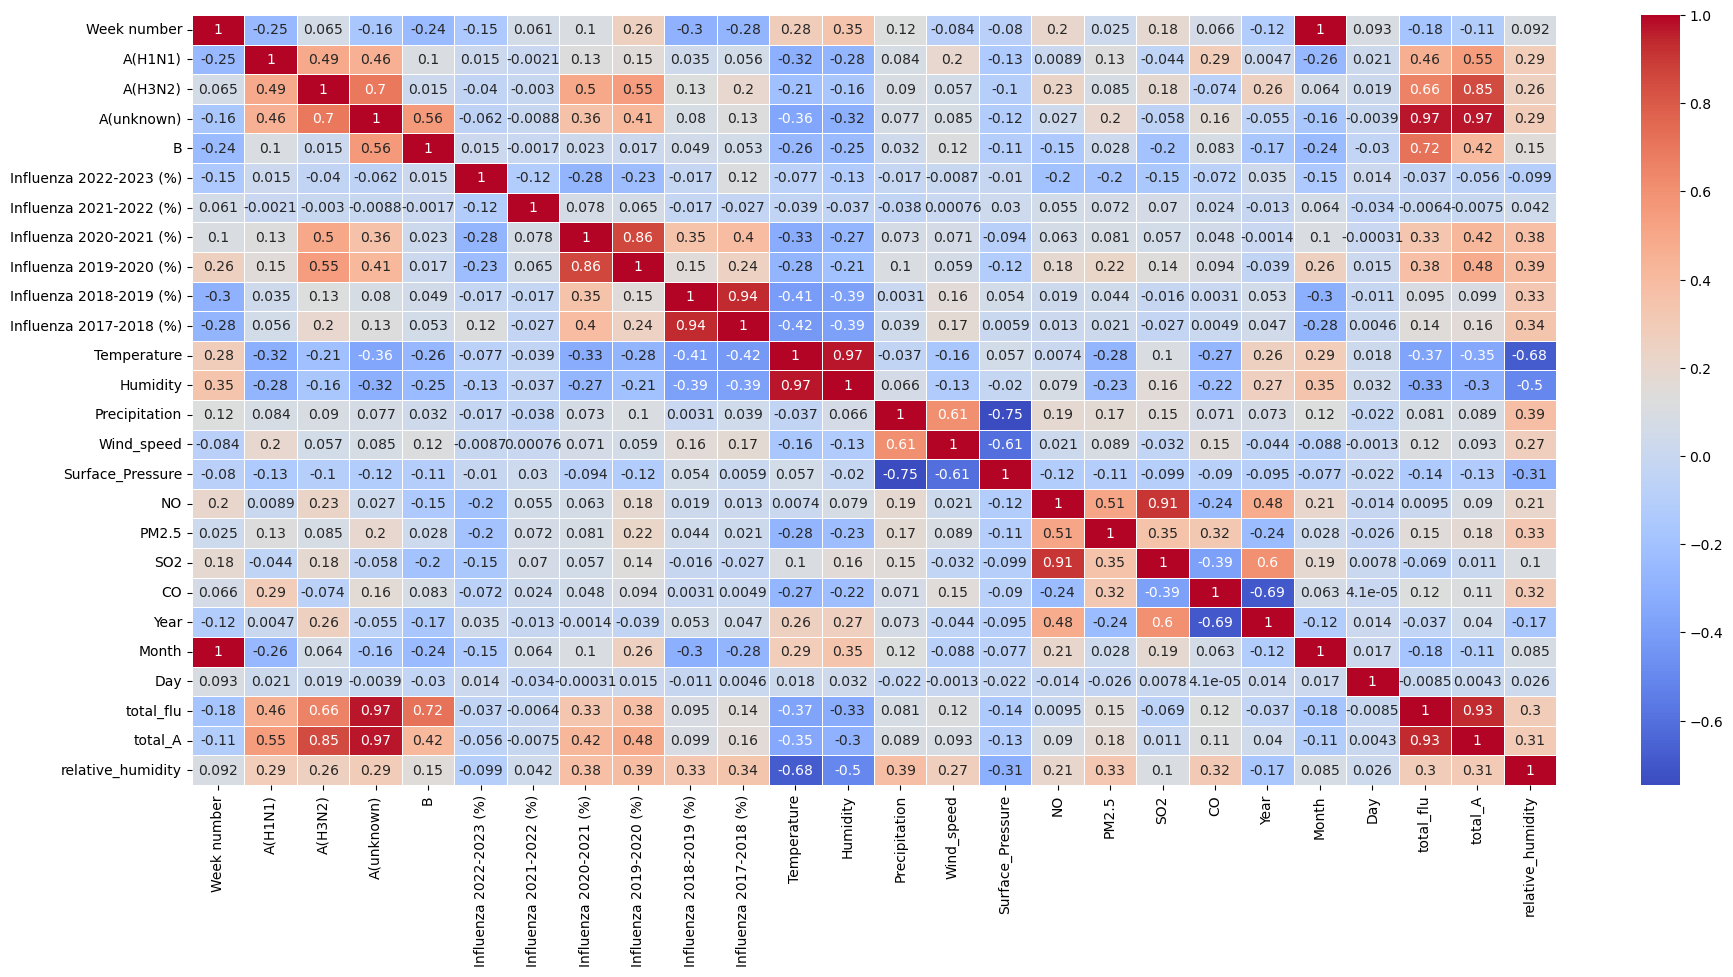

In [32]:
corr_matrix = dfQ.corr()

# Plot the heatmap
plt.figure(figsize=(22, 10))  # Adjust the figure size if needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Show the plot
plt.show()

In [53]:
#create the feature NO_SO2 because of the existing high correlation between them
dfQ['NO_SO2'] = dfQ['NO'] * dfQ['SO2']


In [38]:
# Check for infinity or large values in the feature matrix X
print(np.isinf(dfQ).sum())  # This will show how many infinite values are in each column
print(np.isinf(dfQ).any())  # This will check if there are any infinite values

# Check for very large values
print((dfQ > 1e308).sum())  # This will show how many values are excessively large (greater than float64 limit)



Week number                0
A(H1N1)                    0
A(H3N2)                    0
A(unknown)                 0
B                          0
Influenza 2022-2023 (%)    0
Influenza 2021-2022 (%)    0
Influenza 2020-2021 (%)    0
Influenza 2019-2020 (%)    0
Influenza 2018-2019 (%)    0
Influenza 2017-2018 (%)    0
Temperature                0
Humidity                   0
Precipitation              0
Wind_speed                 0
Surface_Pressure           0
NO                         0
PM2.5                      0
SO2                        0
CO                         0
Year                       0
Month                      0
Day                        0
total_flu                  0
total_A                    0
relative_humidity          0
NO_SO2                     0
dtype: int64
Week number                False
A(H1N1)                    False
A(H3N2)                    False
A(unknown)                 False
B                          False
Influenza 2022-2023 (%)    False
Influe

### Feature Selection 

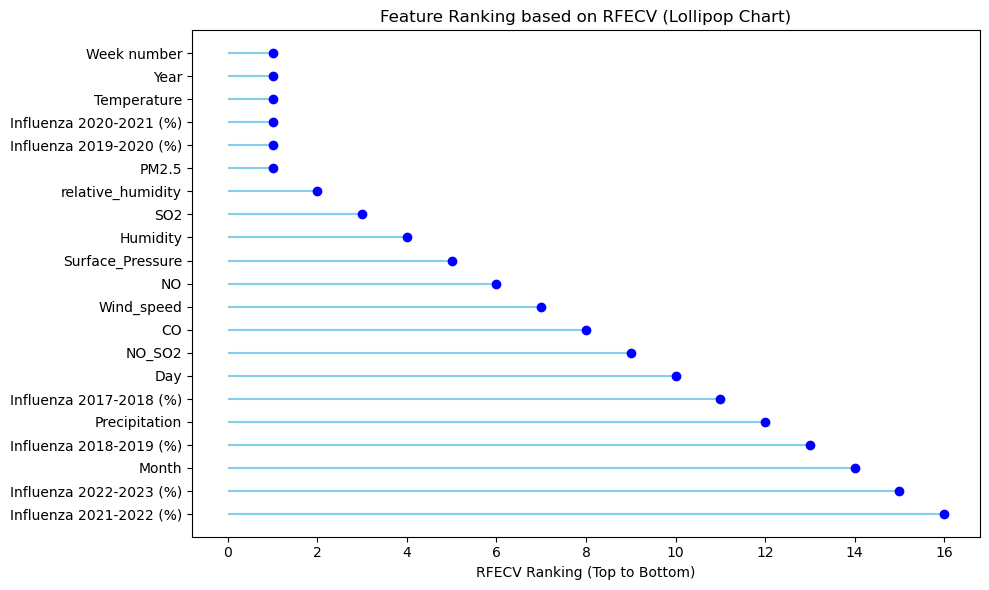

In [41]:
# using recursive feature elimination with cross validation 
# Define features (X) and target (Y)
X = dfQ[['Week number','Influenza 2022-2023 (%)', 'Influenza 2021-2022 (%)', 
          'Influenza 2020-2021 (%)', 'Influenza 2019-2020 (%)', 
          'Influenza 2018-2019 (%)', 'Influenza 2017-2018 (%)', 'NO', 'PM2.5', 
          'SO2', 'CO', 'Temperature', 'Humidity', 'Precipitation', 
          'Wind_speed', 'Surface_Pressure', 'Year', 'Month', 
          'Day', 'NO_SO2', 'relative_humidity']]

Y = dfQ['total_flu']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use RandomForestRegressor with RFECV
rf = RandomForestRegressor(random_state=42)
rfecv = RFECV(estimator=rf, step=1, cv=5)  # Cross-validation with 5 folds
rfecv.fit(X_train_scaled, y_train)

# Get the ranking of the features from RFECV
ranking = rfecv.ranking_
feature_ranking_df = pd.DataFrame({'Feature': X.columns, 'Ranking': ranking})

# Sort the feature ranking for plotting
feature_ranking_df_sorted = feature_ranking_df.sort_values(by='Ranking', ascending=True)

# Lollipop chart for ranking
plt.figure(figsize=(10, 6))
plt.hlines(y=feature_ranking_df_sorted['Feature'], xmin=0, xmax=feature_ranking_df_sorted['Ranking'], color='skyblue')
plt.plot(feature_ranking_df_sorted['Ranking'], feature_ranking_df_sorted['Feature'], 'o', color='blue')
plt.xlabel('RFECV Ranking (Top to Bottom)')
plt.title('Feature Ranking based on RFECV (Lollipop Chart)')
plt.gca().invert_yaxis() 
plt.tight_layout()

# Show the plot
plt.show()

In [46]:
# Using Random Forest to display the feature importance 
#checking with random forest
# NO and SO2 to replace NO_SO2

X = dfQ[['Week number','Influenza 2022-2023 (%)', 'Influenza 2021-2022 (%)', 
          'Influenza 2020-2021 (%)', 'Influenza 2019-2020 (%)', 
          'Influenza 2018-2019 (%)', 'Influenza 2017-2018 (%)', 'NO', 'PM2.5', 
          'SO2', 'CO', 'Temperature', 'Humidity', 'Precipitation', 
          'Wind_speed', 'Surface_Pressure', 'Year', 'Month', 
          'Day', 'NO_SO2', 'relative_humidity']]

Y = dfQ['total_flu']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Fit a RandomForest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances from the trained model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for the feature importances
feature_importance_df = pd.DataFrame({
    'Variables': X.columns,
    'Weight': feature_importances
})

# Sort by importance (optional)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Weight', ascending=False)
feature_importance_df_sorted['Weight'] = feature_importance_df_sorted['Weight'].round(3)

# Display the DataFrame as a table
print(feature_importance_df_sorted)



                  Variables  Weight
16                     Year   0.231
0               Week number   0.158
3   Influenza 2020-2021 (%)   0.110
4   Influenza 2019-2020 (%)   0.074
8                     PM2.5   0.061
11              Temperature   0.054
20        relative_humidity   0.050
9                       SO2   0.037
12                 Humidity   0.037
14               Wind_speed   0.030
15         Surface_Pressure   0.029
7                        NO   0.026
10                       CO   0.025
19                   NO_SO2   0.018
18                      Day   0.016
13            Precipitation   0.012
6   Influenza 2017-2018 (%)   0.012
5   Influenza 2018-2019 (%)   0.010
17                    Month   0.008
2   Influenza 2021-2022 (%)   0.002
1   Influenza 2022-2023 (%)   0.002


In [ ]:
#lets delete the columns that will not be needed as they are less relevant 
# i.e day, Influenza 2018-2019 (%)', 'Influenza 2017-2018 (%)','Influenza 2022-2023 (%),'Influenza 2021-2022 (%)'
#precipitation, month,humidity
# Drop the less relevant columns from dfQ
dfQ.drop(columns=['Day', 'Influenza 2018-2019 (%)', 'Influenza 2017-2018 (%)',
                  'Influenza 2022-2023 (%)', 'Influenza 2021-2022 (%)', 
                  'Precipitation', 'Month','Humidity'], inplace=True)


In [59]:
# Save the feature_matrix to a CSV file
dfQ.to_csv('cstlisten.csv', index=False)